# K-Means -- Cenário 1: Segmentação descritiva (base inteira, sem split)

**Quando usar este notebook:** quando o objetivo é **entender/descrever os
clientes que você já tem** -- por exemplo, "quais perfis de cliente existem
nesta base?". Você não vai usar o modelo depois para classificar gente nova
automaticamente; o resultado é uma análise sobre os dados que estão em mãos
agora.

Por isso, **não separamos treino/teste aqui**: não existe uma pergunta de
"o modelo generaliza para dados novos?" -- só existe "quais grupos aparecem
nos dados que eu tenho?". O tratamento (ausentes, outliers, escala) é
calculado usando a base inteira, porque é a base inteira que será agrupada
e descrita.

> Se o seu objetivo for treinar um modelo para classificar clientes novos
> no futuro, use o outro notebook (Cenário 2 -- Modelo para novos clientes),
> que separa treino/teste e usa `fit` só no treino.

Base usada: `clientes_kmeans.csv` (clientes com idade, renda, visitas,
gasto médio e dias desde a última compra).


## 1. Importações

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

RANDOM_STATE = 42
# Por quê: fixa a semente de tudo que envolve aleatoriedade (inicialização
# do K-Means, simulação de sujeira nos dados) para o notebook ser
# reprodutível.


## 2. Abrir o CSV (como se fosse um arquivo real no seu computador)

Troque `caminho_csv` pelo caminho real do seu arquivo quando for usar com
dados próprios.


In [2]:
caminho_csv = "clientes_kmeans.csv"
df = pd.read_csv(caminho_csv)
# Por quê: carrega o arquivo como DataFrame para podermos manipular.

print("Formato do dataset (linhas, colunas):", df.shape)
df.head()
# Por quê: conferir que o arquivo foi lido corretamente (colunas certas,
# tipos plausíveis).


Formato do dataset (linhas, colunas): (90, 7)


,cliente_id,idade,renda_mensal,visitas_mes,gasto_medio,dias_desde_ultima_compra,perfil_referencia
0,CLI001,31,1881,3,132.49,58,economico
1,CLI002,51,2408,3,220.06,46,economico
2,CLI003,51,2529,1,118.88,49,economico
3,CLI004,26,2769,2,91.25,60,economico
4,CLI005,28,4083,1,116.21,12,economico


## 3. Simular sujeira nos dados (só para fins didáticos)

O `clientes_kmeans.csv` original já está limpo. Introduzimos de propósito
alguns valores ausentes e um outlier para o exemplo ficar realista -- com
seus próprios dados, normalmente você pularia esta célula.


In [3]:
rng = np.random.default_rng(RANDOM_STATE)
df_sujo = df.copy()
# Por quê: trabalhamos numa cópia para preservar o dataset original.

indices_nan = rng.choice(df_sujo.index, size=4, replace=False)
df_sujo.loc[indices_nan, "gasto_medio"] = np.nan
# Por quê: simula um problema comum em bases reais -- valores ausentes.

indice_outlier = rng.choice(df_sujo.index)
df_sujo.loc[indice_outlier, "renda_mensal"] = 400000
# Por quê: simula um erro de digitação/medição -- útil para testar o
# tratamento de outliers mais adiante (importante no K-Means, já que os
# centróides são médias e ficam muito sensíveis a valores extremos).

df = df_sujo
print("Valores ausentes introduzidos em 'gasto_medio':", df['gasto_medio'].isna().sum())


Valores ausentes introduzidos em 'gasto_medio': 4


## 4. Inspeção geral

Só olhamos os dados aqui -- ainda não calculamos nada que será usado para
tratar/imputar/cortar valores.


In [4]:
df.info()
# Por quê: confirma tipos de cada coluna e quantos valores não nulos existem.

df.isnull().sum()
# Por quê: quantidade de ausentes por coluna, para decidir a estratégia de
# imputação.

df.describe()
# Por quê: visão geral de escala e possíveis outliers (min/max/quartis).


<class 'pandas.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   cliente_id                90 non-null     str    
 1   idade                     90 non-null     int64  
 2   renda_mensal              90 non-null     int64  
 3   visitas_mes               90 non-null     int64  
 4   gasto_medio               86 non-null     float64
 5   dias_desde_ultima_compra  90 non-null     int64  
 6   perfil_referencia         90 non-null     str    
dtypes: float64(1), int64(4), str(2)
memory usage: 5.1 KB


,idade,renda_mensal,visitas_mes,gasto_medio,dias_desde_ultima_compra
count,90.000000,90.000000,90.000000,86.000000,90.000000
mean,41.655556,11085.188889,4.922222,553.069070,21.644444
std,10.373000,41609.526409,2.623266,445.643514,16.405885
min,18.000000,1881.000000,1.000000,58.600000,1.000000
25%,34.000000,3508.000000,3.000000,145.740000,9.250000
50%,42.000000,5872.500000,5.000000,377.970000,16.000000
75%,49.000000,10526.250000,7.000000,1079.127500,31.750000
max,62.000000,400000.000000,11.000000,1404.580000,70.000000


## 5. Selecionar os atributos usados no agrupamento

`cliente_id` é só um identificador (sem valor para o agrupamento).
`perfil_referencia` é um rótulo que existe **apenas neste dataset
didático**, para conferência -- num caso real, normalmente você não teria
esse rótulo (é justamente o que o K-Means tentaria descobrir sozinho).
Vamos guardá-lo à parte, sem usá-lo no treinamento do modelo.


In [5]:
colunas_features = [
    "idade",
    "renda_mensal",
    "visitas_mes",
    "gasto_medio",
    "dias_desde_ultima_compra",
]
X = df[colunas_features].copy()
perfil_referencia = df["perfil_referencia"]
# Por quê separar assim: X é o que realmente entra no K-Means (não
# supervisionado -- não existe "y" no treinamento). perfil_referencia fica
# guardado só para conferirmos depois, de forma honesta, se os grupos
# encontrados fazem sentido.


## 6. Tratar valores ausentes -- calculado com a base inteira

Aqui não há treino/teste: usamos a base inteira para aprender e aplicar a
imputação, porque é a base inteira que queremos descrever.


In [6]:
imputer = SimpleImputer(strategy="median")
# Por quê median: é menos afetada por outliers do que a média ao ser
# calculada -- mas repare que isso não remove o outlier em si, só evita que
# ele distorça o valor usado para preencher os ausentes.

X_imputado = pd.DataFrame(
    imputer.fit_transform(X),
    columns=colunas_features,
    index=X.index,
)
# Por quê fit_transform na base inteira: não existe "vazamento" aqui porque
# não há uma parte reservada para avaliação -- toda a base é o que será
# agrupado e descrito.


## 7. Tratar outliers -- limites de IQR calculados com a base inteira

In [7]:
def calcular_limites_iqr(serie):
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr
# Por quê: função reutilizável para não repetir a mesma conta em cada coluna.

X_tratado = X_imputado.copy()
for coluna in colunas_features:
    limite_inf, limite_sup = calcular_limites_iqr(X_tratado[coluna])
    X_tratado[coluna] = X_tratado[coluna].clip(limite_inf, limite_sup)
# Por quê tratar outlier em TODAS as colunas (não só renda_mensal): no
# K-Means, qualquer atributo com outlier pode puxar um centróide inteiro --
# diferente do K-NN, onde o efeito fica mais restrito à vizinhança local.

print("Maior valor de renda_mensal após o tratamento:", X_tratado["renda_mensal"].max())


Maior valor de renda_mensal após o tratamento: 21053.625


## 8. Padronizar os atributos

O K-Means usa distância euclidiana entre os pontos e os centróides -- sem
padronizar, `renda_mensal` (na casa dos milhares) dominaria completamente
`idade` ou `visitas_mes` (dezenas) no cálculo de distância.


In [8]:
scaler = StandardScaler()
X_final = scaler.fit_transform(X_tratado)
# Por quê fit_transform na base inteira: mesma lógica do passo 6 -- não há
# divisão treino/teste neste cenário, então ajustamos e aplicamos de uma vez
# só, na base que será efetivamente agrupada.


## 9. Escolher o número de grupos (k) -- método do cotovelo e silhueta

Testamos vários valores de k e olhamos duas coisas: a inércia (quão
compactos ficam os grupos -- método do cotovelo) e a silhueta (quão bem
separados os grupos ficam entre si).


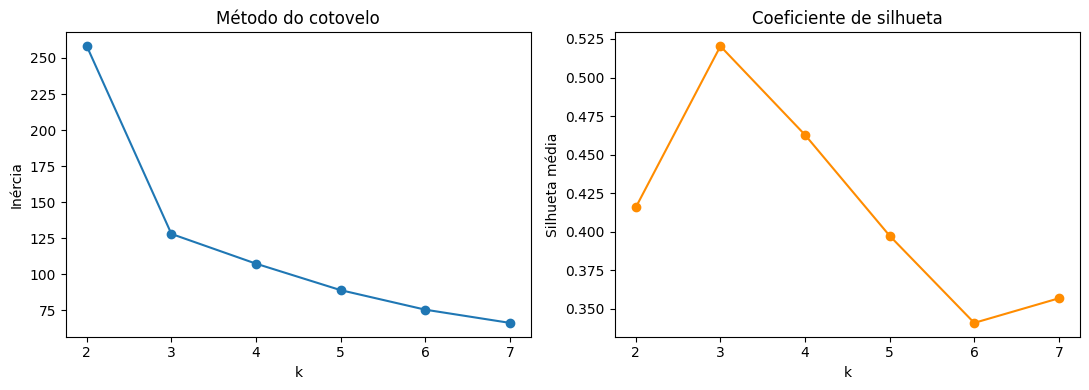

In [9]:
valores_k = range(2, 8)
inercias = []
silhuetas = []

for k in valores_k:
    modelo_k = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels_k = modelo_k.fit_predict(X_final)
    inercias.append(modelo_k.inertia_)
    silhuetas.append(silhouette_score(X_final, labels_k))
# Por quê testar vários k: o K-Means exige que a gente escolha k -- não tem
# como "aprender" isso sozinho. Comparamos várias opções antes de decidir.
# Por quê n_init=10: roda o algoritmo 10 vezes com inicializações diferentes
# e fica com a melhor -- o K-Means é sensível ao ponto de partida.

fig, eixos = plt.subplots(1, 2, figsize=(11, 4))
eixos[0].plot(list(valores_k), inercias, marker="o")
eixos[0].set_title("Método do cotovelo")
eixos[0].set_xlabel("k")
eixos[0].set_ylabel("Inércia")

eixos[1].plot(list(valores_k), silhuetas, marker="o", color="darkorange")
eixos[1].set_title("Coeficiente de silhueta")
eixos[1].set_xlabel("k")
eixos[1].set_ylabel("Silhueta média")
plt.tight_layout()
plt.show()
# Por quê os dois gráficos juntos: o cotovelo mostra onde o ganho de reduzir
# a inércia começa a "achatar"; a silhueta mostra diretamente qual k separa
# melhor os grupos. Usamos os dois porque o cotovelo às vezes é ambíguo.


## 10. Treinar o K-Means final

Este dataset foi montado com 3 perfis de referência (`economico`,
`frequente`, `premium`), então vamos seguir com **k = 3** -- ajuste esse
valor de acordo com o que os gráficos acima mostrarem nos seus próprios
dados.


In [10]:
K_ESCOLHIDO = 3
modelo_kmeans = KMeans(n_clusters=K_ESCOLHIDO, random_state=RANDOM_STATE, n_init=10)
df["cluster"] = modelo_kmeans.fit_predict(X_final)
# Por quê fit_predict na base inteira: aqui treinamos e já atribuímos cada
# cliente a um grupo, tudo de uma vez -- de novo, sem treino/teste, porque
# o objetivo é descrever esta base, não prever em dados futuros.

df["cluster"].value_counts().sort_index()


cluster
0    30
1    30
2    30
Name: count, dtype: int64

## 11. Interpretar os grupos encontrados

In [11]:
perfil_dos_grupos = df.groupby("cluster")[colunas_features].mean().round(1)
print(perfil_dos_grupos)
# Por quê: a média de cada atributo por cluster é a forma mais direta de
# "dar nome" a cada grupo (ex.: cluster com renda alta e muitas visitas =
# provavelmente o perfil "premium").

print("\nComparação com o rótulo de referência (só para conferência):")
print(pd.crosstab(df["cluster"], df["perfil_referencia"]))
# Por quê: como este dataset é didático, temos um rótulo de referência para
# checar se os clusters bateram com os perfis esperados. Em um caso real,
# geralmente você NÃO teria esse rótulo -- é o próprio motivo de usar
# agrupamento (descobrir grupos que você ainda não conhece).


         idade  renda_mensal  visitas_mes  gasto_medio  \
cluster                                                  
0         34.5        5892.1          7.9        387.0   
1         47.2       24300.2          4.6       1145.2   
2         43.3        3063.3          2.3        121.3   

         dias_desde_ultima_compra  
cluster                            
0                             6.8  
1                            17.8  
2                            40.3  

Comparação com o rótulo de referência (só para conferência):
perfil_referencia  economico  frequente  premium
cluster                                         
0                          0         30        0
1                          0          0       30
2                         30          0        0


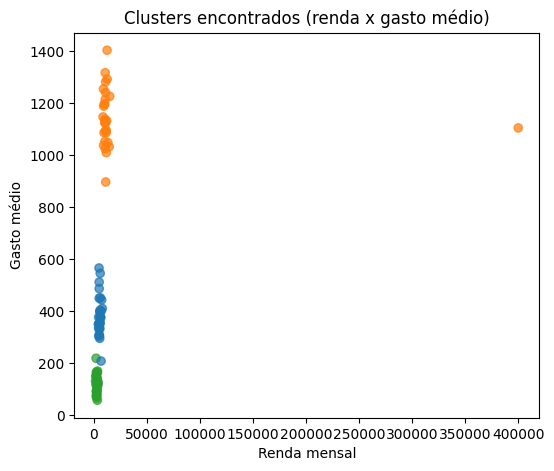

In [12]:
plt.figure(figsize=(6, 5))
cores = df["cluster"].map({0: "tab:blue", 1: "tab:orange", 2: "tab:green"})
plt.scatter(df["renda_mensal"], df["gasto_medio"], c=cores, alpha=0.7)
plt.xlabel("Renda mensal")
plt.ylabel("Gasto médio")
plt.title("Clusters encontrados (renda x gasto médio)")
plt.show()
# Por quê visualizar com duas colunas originais (não padronizadas): fica
# mais fácil de interpretar em termos de negócio do que olhar os valores já
# escalados.


## Resumo -- Cenário 1

- Não houve divisão treino/teste: **toda a base foi tratada e agrupada de
  uma vez**, porque o objetivo era descrever os clientes que já existem.
- Ausentes, outliers e escala foram calculados e aplicados na base inteira
  -- não há "vazamento" porque não existe uma parte reservada para medir
  generalização.
- O resultado (`df["cluster"]`) é uma **análise** desta base específica --
  não um modelo pronto para classificar clientes que ainda vão chegar.

**Se o objetivo mudar** para "quero usar isso para classificar automaticamente
clientes novos que ainda vão se cadastrar", use o notebook do **Cenário 2**.
